# Fully-Occluded Condition (FOC) Analysis

Characterises what each fill type sounds like to each model: modal top-1/top-2 class, confidence, and top-5 mass fraction across the 22-class eval set. Outputs `foc_analysis.csv`, `foc_table.csv`, `foc_per_class_top1.csv`, and figures.


In [ ]:
# ── USER CONFIG ──────────────────────────────────────────────────────────────
DATA_ROOT  = "/path/to/data" # root: {model}/{cls}/embs/
OUTPUT_DIR = "/path/to/outputs/foc" # where CSVs are written
LABELS_CSV = "/path/to/partial_mask_geometry_xai/models_and_data/class_labels_indices.csv"
# ─────────────────────────────────────────────────────────────────────────────
print(f"Data root : {DATA_ROOT}\n"
      f"Output dir: {OUTPUT_DIR}\n"
      f"Labels CSV: {LABELS_CSV}")


In [ ]:
import os
import csv
import numpy as np

os.makedirs(OUTPUT_DIR, exist_ok=True)

N_MASKS_PER_CLIP = 9600
MASK_DIMS = {
    "ast_wrapper":           (128, 101),
    "panns_no_specaug":      ( 64, 100),
    "panns_specaug_trained": ( 64, 100),
}
MODELS = ["ast_wrapper", "panns_no_specaug", "panns_specaug_trained"]
N_CLASSES = 527
CLASSES = [
    "bagpipes", "boing", "chicken_rooster", "didgeridoo", "dog", "drum_kit",
    "frog", "frying_food", "gunshot_gunfire", "hair_dryer", "harmonica",
    "heart_sounds_heartbeat", "insect", "owl", "rain", "rub", "sewing_machine",
    "speech", "thunder", "timpani", "train", "whispering",
]

with open(LABELS_CSV) as f:
    idx_to_name = {int(row["index"]): row["display_name"] for row in csv.DictReader(f)}

def _slug(name):
    return name.replace(", ", "_").replace(" ", "_").replace("(", "").replace(")", "").lower()

slug_to_gt = {_slug(n): (i, n) for i, n in idx_to_name.items()}
gt_idx  = {}  # cls -> AudioSet integer index
gt_name = {}  # cls -> AudioSet display name
for cls in CLASSES:
    if cls in slug_to_gt:
        gt_idx[cls], gt_name[cls] = slug_to_gt[cls]
    else:
        print(f"WARNING: no GT match for {cls}")

print(f"Setup complete -- {len(MODELS)} models, {len(CLASSES)} classes, {len(idx_to_name)} AudioSet labels")

In [ ]:
FILL_SUFFIXES = {
    "foc_zero":           "_foc_zero.npy",
    "foc_mean":           "_foc_mean.npy",
    "foc_gaussian_noise": "_foc_gaussian_noise.npy",
}

data   = {}
totals = {"orig": 0, **{k: 0 for k in FILL_SUFFIXES}}

for model in MODELS:
    data[model] = {}
    for cls in CLASSES:
        embs_dir = os.path.join(DATA_ROOT, model, cls, "embs")
        if not os.path.isdir(embs_dir):
            print(f"  WARN: {model}/{cls}/embs not found")
            continue

        orig_files = sorted(f for f in os.listdir(embs_dir)
                            if f.endswith("_original_sigmoid.npy"))
        if not orig_files:
            print(f"  WARN: no original sigmoid for {model}/{cls}")
            continue

        n_orig = len(orig_files)
        data[model][cls] = {
            "orig": np.stack([np.load(os.path.join(embs_dir, f), allow_pickle=False).astype(np.float32)
                              for f in orig_files]) # (n_clips, 527)
        }
        totals["orig"] += n_orig

        for fill_key, suffix in FILL_SUFFIXES.items():
            fill_files = sorted(f for f in os.listdir(embs_dir) if f.endswith(suffix))
            if not fill_files:
                print(f"  WARN: no {fill_key} files for {model}/{cls}")
                continue
            if len(fill_files) != n_orig:
                print(f"  WARN: clip count mismatch {model}/{cls} {fill_key}: orig={n_orig} fill={len(fill_files)} — skipping")
                continue
            data[model][cls][fill_key] = np.stack([
                np.load(os.path.join(embs_dir, f), allow_pickle=False).astype(np.float32)
                for f in fill_files
            ])  # (n_clips, 527)
            totals[fill_key] += len(fill_files)

print(f"orig              : {totals['orig']}  (expected 3297)")
for k in FILL_SUFFIXES:
    print(f"{k:<22}: {totals[k]}  (expected 3297)")

orig              : 3297  (expected 3297)
foc_zero              : 3297  (expected 3297)
foc_mean              : 3297  (expected 3297)
foc_gaussian_noise    : 3297  (expected 3297)


## Model accuracy on the eval set

Fraction of original clips where argmax of the sigmoid matches the GT class index, per (model, class).

In [ ]:
model_accuracy = {}  # model -> cls -> fraction of clips where argmax == GT index

for model in MODELS:
    model_accuracy[model] = {}
    print(f"\n{model}")
    print(f"  {'class':<28} {'accuracy':>10}  model top-1")
    print("  " + "-" * 60)
    for cls in CLASSES:
        if cls not in data[model] or cls not in gt_idx:
            continue
        k        = gt_idx[cls]
        argmaxes = np.argmax(data[model][cls]["orig"], axis=1)
        acc      = float((argmaxes == k).mean())
        top1_idx = int(np.bincount(argmaxes).argmax())
        top1     = idx_to_name.get(top1_idx, "?")
        model_accuracy[model][cls] = acc
        flag = "" if acc >= 0.5 else "  ← low"
        print(f"  {cls:<28} {acc:>9.0%}  {top1}{flag}")

In [ ]:
KEYS = ["gt_sigmoid", "gt_sigmoid_std", "foc_gt_sigmoid", "delta_gt_sigmoid", "gt_rank", "foc_gt_rank"]

def _row(label, s):
    return (f"  {label:<38} "
            f"{np.mean(s['gt_sigmoid']):7.4f} {np.nanmean(s['gt_sigmoid_std']):7.4f} "
            f"{np.mean(s['foc_gt_sigmoid']):7.4f} {np.mean(s['delta_gt_sigmoid']):+8.4f} "
            f"{np.mean(s['gt_rank']):7.1f} {np.mean(s['foc_gt_rank']):7.1f}")

def _std(label, s):
    n = len(s["gt_sigmoid"])
    if n < 2:
        return f"  {label:<38} n/a (n<2)"
    return (f"  {label:<38} "
            f"{np.std(s['gt_sigmoid'], ddof=1):7.4f} {'n/a':>7} "
            f"{np.std(s['foc_gt_sigmoid'], ddof=1):7.4f} {np.std(s['delta_gt_sigmoid'], ddof=1):+8.4f} "
            f"{np.std(s['gt_rank'], ddof=1):7.1f} {np.std(s['foc_gt_rank'], ddof=1):7.1f}")

header = (f"{'Model':<24} {'class':<22} "
          f"{'gt_sig':>7} {'sig_std':>7} {'foc_sig':>7} {'delta':>8} "
          f"{'gt_rank':>7} {'foc_rank':>8} {'acc':>6}")

# Pre-compute orig_* stats once (depend only on original clips, not fill condition)
orig_stats = {}
for model in MODELS:
    orig_stats[model] = {}
    for cls in CLASSES:
        if cls not in data[model] or cls not in gt_idx:
            continue
        orig_vecs = data[model][cls]["orig"]
        n_clips   = orig_vecs.shape[0]
        k         = gt_idx[cls]
        orig_at_k = orig_vecs[:, k]
        orig_stats[model][cls] = {
            "gt_sigmoid":     float(orig_at_k.mean()),
            "gt_sigmoid_std": float(orig_at_k.std(ddof=1)) if n_clips > 1 else float("nan"),
            "gt_rank":        float(np.mean(np.sum(orig_vecs >= orig_vecs[:, k:k+1], axis=1))),
        }

all_rows = []

for fill in FILL_SUFFIXES:
    print(f"\n{'='*50} {fill} {'='*50}")
    print(header)
    print("-" * 100)

    summary = {m: {key: [] for key in KEYS} for m in MODELS}

    for model in MODELS:
        for cls in CLASSES:
            if cls not in data[model] or fill not in data[model][cls] or cls not in orig_stats.get(model, {}):
                continue

            os_              = orig_stats[model][cls]
            gt_sigmoid       = os_["gt_sigmoid"]
            gt_sigmoid_std   = os_["gt_sigmoid_std"]
            gt_rank          = os_["gt_rank"]
            k                = gt_idx[cls]
            acc              = model_accuracy.get(model, {}).get(cls, float("nan"))

            foc_vecs         = data[model][cls][fill]
            foc_gt_sigmoid   = float(foc_vecs[:, k].mean())
            delta_gt_sigmoid = foc_gt_sigmoid - gt_sigmoid
            foc_gt_rank      = float(np.mean(np.sum(foc_vecs >= foc_vecs[:, k:k+1], axis=1)))

            vals = dict(gt_sigmoid=gt_sigmoid, gt_sigmoid_std=gt_sigmoid_std,
                        foc_gt_sigmoid=foc_gt_sigmoid, delta_gt_sigmoid=delta_gt_sigmoid,
                        gt_rank=gt_rank, foc_gt_rank=foc_gt_rank)
            for key, v in vals.items():
                summary[model][key].append(v)

            all_rows.append({
                "model":            model,
                "class":            cls,
                "fill":             fill,
                "gt_idx":           k,
                "gt_label":         gt_name.get(cls, "?"),
                "accuracy":         round(acc, 4) if not np.isnan(acc) else float("nan"),
                "gt_sigmoid":       round(gt_sigmoid, 6),
                "gt_sigmoid_std":   float("nan") if np.isnan(gt_sigmoid_std) else round(gt_sigmoid_std, 6),
                "foc_gt_sigmoid":   round(foc_gt_sigmoid, 6),
                "delta_gt_sigmoid": round(delta_gt_sigmoid, 6),
                "gt_rank":          round(gt_rank, 2),
                "foc_gt_rank":      round(foc_gt_rank, 2),
            })

            std_str = f"{gt_sigmoid_std:7.4f}" if not np.isnan(gt_sigmoid_std) else "    nan"
            acc_str = f"{acc:5.0%}" if not np.isnan(acc) else "  n/a"
            print(f"{model:<24} {cls:<22} "
                  f"{gt_sigmoid:7.4f} {std_str} {foc_gt_sigmoid:7.4f} {delta_gt_sigmoid:+8.4f} "
                  f"{gt_rank:7.1f} {foc_gt_rank:8.1f} {acc_str:>6}")

        s = summary[model]
        n = len(s["gt_sigmoid"])
        print(_row(f"({n}) MEAN", s))
        print(_std(f"({n}) STD",  s))
        print()

print(f"\nCollected {len(all_rows)} rows total  "
      f"({len(MODELS)} models × {len(CLASSES)} classes × {len(FILL_SUFFIXES)} fills = "
      f"{len(MODELS)*len(CLASSES)*len(FILL_SUFFIXES)} expected)")


In [ ]:
_CSV_OUT = os.path.join(OUTPUT_DIR, "foc_analysis.csv")

fieldnames = [
    "model", "class", "fill",
    "gt_idx", "gt_label", "accuracy",
    "gt_sigmoid", "gt_sigmoid_std", "foc_gt_sigmoid", "delta_gt_sigmoid",
    "gt_rank", "foc_gt_rank",
]

with open(_CSV_OUT, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_rows)

print(f"Saved {len(all_rows)} rows → {_CSV_OUT}")


## FOC Fingerprint Table

For each (model, fill): modal top-1/top-2 predicted class and confidence (p ± σ), both conditional (when ranked top-1/2) and unconditional (all clips).


In [ ]:
FILL_KEYS = ["foc_zero", "foc_mean", "foc_gaussian_noise"]
FILL_DISPLAY = {
    "foc_zero":           "Zero",
    "foc_mean":           "Mean",
    "foc_gaussian_noise": "Gaussian noise",
}

foc_table = {}  # [model][fill_key] -> dict of stats

for model in MODELS:
    foc_table[model] = {}

    for fill_key in FILL_KEYS:
        parts = [data[model][cls][fill_key]
                 for cls in CLASSES
                 if cls in data[model] and fill_key in data[model][cls]]

        if not parts:
            print(f"  WARN: no data for {model} / {fill_key}")
            continue

        pooled = np.concatenate(parts, axis=0).astype(np.float32)  # (N, 527)
        N = pooled.shape[0]

        mean_vec = pooled.mean(axis=0)  # (527,)

        modal_top1 = int(mean_vec.argmax())
        mean_vec_excl = mean_vec.copy()
        mean_vec_excl[modal_top1] = -1.0
        modal_top2 = int(mean_vec_excl.argmax())

        top1_idx = np.argmax(pooled, axis=1)
        top2_idx = np.argsort(-pooled, axis=1)[:, 1]

        n_top1 = int((top1_idx == modal_top1).sum())
        n_top2 = int((top2_idx == modal_top2).sum())

        p1_vals = pooled[top1_idx == modal_top1, modal_top1]
        p2_vals = pooled[top2_idx == modal_top2, modal_top2]

        p1_mean = float(p1_vals.mean()) if len(p1_vals) > 0 else float("nan")
        p1_std  = float(p1_vals.std(ddof=1)) if len(p1_vals) > 1 else 0.0
        p2_mean = float(p2_vals.mean()) if len(p2_vals) > 0 else float("nan")
        p2_std  = float(p2_vals.std(ddof=1)) if len(p2_vals) > 1 else 0.0

        p1_all_vals = pooled[:, modal_top1]
        p2_all_vals = pooled[:, modal_top2]

        p1_all_mean = float(p1_all_vals.mean())
        p1_all_std  = float(p1_all_vals.std(ddof=1)) if N > 1 else 0.0
        p2_all_mean = float(p2_all_vals.mean())
        p2_all_std  = float(p2_all_vals.std(ddof=1)) if N > 1 else 0.0

        if fill_key == "foc_zero":
            for cls in CLASSES:
                if cls in data[model] and fill_key in data[model][cls]:
                    within_std = float(data[model][cls][fill_key].std(axis=0).max())
                    if within_std > 1e-4:
                        print(f"  WARN: zero fill within {cls}/{model} max std = {within_std:.6f}")

        foc_table[model][fill_key] = {
            "N":               N,
            "modal_top1":      modal_top1,
            "modal_top1_name": idx_to_name.get(modal_top1, "?"),
            "n_top1":          n_top1,
            "p1_mean":         p1_mean,
            "p1_std":          p1_std,
            "p1_all_mean":     p1_all_mean,
            "p1_all_std":      p1_all_std,
            "modal_top2":      modal_top2,
            "modal_top2_name": idx_to_name.get(modal_top2, "?"),
            "n_top2":          n_top2,
            "p2_mean":         p2_mean,
            "p2_std":          p2_std,
            "p2_all_mean":     p2_all_mean,
            "p2_all_std":      p2_all_std,
            "mean_vec":        mean_vec,
        }

print("FOC table computed.")
print()
print(f"{'model':<28} {'fill':<18} {'N':>5}  "
      f"top-1 class              n/N    p|top1±σ         p|all±σ           "
      f"top-2 class              n/N    p|top2±σ         p|all±σ")
print("-" * 200)

MODEL_LABELS = {
    "ast_wrapper":           "AST",
    "panns_no_specaug":      "PANNs (no SA)",
    "panns_specaug_trained": "PANNs (+SA)",
}

for model in MODELS:
    for fill_key in FILL_KEYS:
        if fill_key not in foc_table[model]:
            continue
        r = foc_table[model][fill_key]
        is_zero = fill_key == "foc_zero"
        p1c = f"{r['p1_mean']:.3f}" if is_zero else f"{r['p1_mean']:.3f}±{r['p1_std']:.3f}"
        p1u = f"{r['p1_all_mean']:.3f}" if is_zero else f"{r['p1_all_mean']:.3f}±{r['p1_all_std']:.3f}"
        p2c = f"{r['p2_mean']:.3f}" if is_zero else f"{r['p2_mean']:.3f}±{r['p2_std']:.3f}"
        p2u = f"{r['p2_all_mean']:.3f}" if is_zero else f"{r['p2_all_mean']:.3f}±{r['p2_all_std']:.3f}"
        print(f"{MODEL_LABELS[model]:<28} {FILL_DISPLAY[fill_key]:<18} {r['N']:>5}  "
              f"{r['modal_top1_name']:<24} {r['n_top1']:>4}/{r['N']}  {p1c:<16}  {p1u:<16}  "
              f"{r['modal_top2_name']:<24} {r['n_top2']:>4}/{r['N']}  {p2c:<16}  {p2u:<16}")

print()
print("Top-2 by mean sigmoid — signal-dependent fills (mean & Gaussian noise)")
print("─" * 70)
for model in MODELS:
    for fill_key in ["foc_mean", "foc_gaussian_noise"]:
        if fill_key not in foc_table.get(model, {}):
            continue
        r = foc_table[model][fill_key]
        mv = r["mean_vec"]
        ranked = np.argsort(-mv)
        k1, k2 = int(ranked[0]), int(ranked[1])
        print(f"  {MODEL_LABELS[model]:<14} {FILL_DISPLAY[fill_key]:<16}"
              f"  1. {idx_to_name.get(k1,'?'):<28}  p̄ = {mv[k1]:.4f}"
              f"  |  2. {idx_to_name.get(k2,'?'):<28}  p̄ = {mv[k2]:.4f}")


In [ ]:
_FOC_TABLE_CSV = os.path.join(OUTPUT_DIR, "foc_table.csv")

_FIELDS = [
    "model", "fill", "N",
    "modal_top1", "modal_top1_name", "n_top1",
    "p1_mean", "p1_std",
    "p1_all_mean", "p1_all_std",
    "modal_top2", "modal_top2_name", "n_top2",
    "p2_mean", "p2_std",
    "p2_all_mean", "p2_all_std",
]

rows = []
for model in MODELS:
    for fill_key in FILL_KEYS:
        if fill_key not in foc_table.get(model, {}):
            continue
        r = foc_table[model][fill_key]
        rows.append({
            "model":           model,
            "fill":            fill_key,
            "N":               r["N"],
            "modal_top1":      r["modal_top1"],
            "modal_top1_name": r["modal_top1_name"],
            "n_top1":          r["n_top1"],
            "p1_mean":         round(r["p1_mean"],     6),
            "p1_std":          round(r["p1_std"],      6),
            "p1_all_mean":     round(r["p1_all_mean"], 6),
            "p1_all_std":      round(r["p1_all_std"],  6),
            "modal_top2":      r["modal_top2"],
            "modal_top2_name": r["modal_top2_name"],
            "n_top2":          r["n_top2"],
            "p2_mean":         round(r["p2_mean"],     6),
            "p2_std":          round(r["p2_std"],      6),
            "p2_all_mean":     round(r["p2_all_mean"], 6),
            "p2_all_std":      round(r["p2_all_std"],  6),
        })

with open(_FOC_TABLE_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=_FIELDS)
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved {len(rows)} rows → {_FOC_TABLE_CSV}")


In [ ]:
# Per-GT-class top-1 under mean and Gaussian fills (heatmap data)
# For each (model, fill, GT-class) find the modal top-1 class by mean sigmoid.
# Zero fill is signal-independent — per-class breakdown adds no information there.

HEATMAP_FILLS = ["foc_mean", "foc_gaussian_noise"]

foc_per_class_top1 = {}   # [model][fill_key][cls] -> dict

print("Per-GT-class modal top-1 under mean and Gaussian fills")
print(f"{'model':<28} {'fill':<22} {'GT class':<28}  top-1 class              p_mean")
print("-" * 100)

for model in MODELS:
    foc_per_class_top1[model] = {}
    for fill_key in HEATMAP_FILLS:
        foc_per_class_top1[model][fill_key] = {}
        for cls in CLASSES:
            if cls not in data[model] or fill_key not in data[model][cls]:
                continue
            arr      = data[model][cls][fill_key].astype(np.float64)   # (n_clips, 527)
            mean_vec = arr.mean(axis=0)
            top1_idx  = int(mean_vec.argmax())
            top1_name = idx_to_name.get(top1_idx, "?")
            top1_p    = float(mean_vec[top1_idx])
            foc_per_class_top1[model][fill_key][cls] = {
                "top1_idx":  top1_idx,
                "top1_name": top1_name,
                "top1_p":    top1_p,
            }
            print(f"{MODEL_LABELS[model]:<28} {FILL_DISPLAY[fill_key]:<22} {cls:<28}  {top1_name:<24} {top1_p:.3f}")
        print()

# Heatmap aggregate: count how many GT classes share each top-1 class
print()
print("Heatmap counts (n GT classes → top-1 class)")
print(f"{'model':<28} {'fill':<22}  top-1 class              count/22")
print("-" * 80)
for model in MODELS:
    for fill_key in HEATMAP_FILLS:
        from collections import Counter
        counts = Counter(v["top1_name"]
                         for v in foc_per_class_top1[model][fill_key].values())
        n_total = len(foc_per_class_top1[model][fill_key])
        for name, cnt in counts.most_common():
            print(f"{MODEL_LABELS[model]:<28} {FILL_DISPLAY[fill_key]:<22}  {name:<24} {cnt}/{n_total}")
        print()

# Save to CSV
_HEATMAP_CSV = os.path.join(OUTPUT_DIR, "foc_per_class_top1.csv")
_HEATMAP_FIELDS = ["model", "fill_key", "gt_cls", "top1_idx", "top1_name", "top1_p"]
heatmap_rows = []
for model in MODELS:
    for fill_key in HEATMAP_FILLS:
        for cls in CLASSES:
            entry = foc_per_class_top1[model].get(fill_key, {}).get(cls)
            if entry is None:
                continue
            heatmap_rows.append({
                "model":    model,
                "fill_key": fill_key,
                "gt_cls":   cls,
                "top1_idx": entry["top1_idx"],
                "top1_name":entry["top1_name"],
                "top1_p":   round(entry["top1_p"], 6),
            })

import csv
with open(_HEATMAP_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=_HEATMAP_FIELDS)
    writer.writeheader()
    writer.writerows(heatmap_rows)
print(f"Saved {len(heatmap_rows)} rows → {_HEATMAP_CSV}")


# FOC Analysis — Visualisations

Reads `foc_analysis.csv` from OUTPUT_DIR. Produces Table 1 (zero-fill fingerprint), Figure 4 (top-1 vs top-5 confidence), and per-fill numeric summaries.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CSV_PATH    = os.path.join(OUTPUT_DIR, "foc_analysis.csv")
LABELS_PATH = LABELS_CSV

FILLS  = ["zero", "mean", "gaussian_noise"]
MODELS = ["ast_wrapper", "panns_no_specaug", "panns_specaug_trained"]

MODEL_LABELS = {
    "ast_wrapper":           "AST",
    "panns_no_specaug":      "PANNs (no SA)",
    "panns_specaug_trained": "PANNs (SA)",
}
FILL_LABELS = {
    "zero":           "Zero",
    "mean":           "Mean",
    "gaussian_noise": "Gaussian noise",
}
COLORS = {"zero": "#ef7b45", "mean": "#5eb1bf", "gaussian_noise": "#918ef4"}
MODEL_COLORS = {
    "ast_wrapper":           "#2C5F8A",
    "panns_no_specaug":      "#6B3D7A",
    "panns_specaug_trained": "#2D6A4F",
}
MODEL_MARKERS = {
    "ast_wrapper":           "o",
    "panns_no_specaug":      "s",
    "panns_specaug_trained": "^",
}

plt.rcParams.update({
    "figure.dpi":                    300,
    "font.family":                   "serif",
    "font.size":                     8,
    "axes.labelsize":                8,
    "axes.titlesize":                8,
    "xtick.labelsize":               7,
    "ytick.labelsize":               7,
    "legend.fontsize":               7,
    "legend.frameon":                False,
    "lines.linewidth":               1.5,
    "axes.spines.top":               False,
    "axes.spines.right":             False,
    "axes.linewidth":                0.6,
    "xtick.major.width":             0.6,
    "ytick.major.width":             0.6,
    "xtick.major.size":              3,
    "ytick.major.size":              3,
    "figure.constrained_layout.use": True,
})


In [5]:
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows -- {df['model'].nunique()} models, {df['fill'].nunique()} fills, {df['class'].nunique()} classes")

ldf = pd.read_csv(LABELS_PATH)
idx_col  = "index"        if "index"        in ldf.columns else ldf.columns[0]
name_col = "display_name" if "display_name" in ldf.columns else ldf.columns[2]
idx_to_name = dict(zip(ldf[idx_col].astype(int), ldf[name_col]))


Loaded 210 rows
Models  : ['ast_wrapper', 'panns_no_specaug', 'panns_specaug_trained']
Fills   : ['gaussian_noise', 'mean', 'zero']
Classes : 24 — ['bagpipes', 'boing', 'chicken_rooster', 'didgeridoo', 'dog', 'drum_kit', 'frog', 'frying_food', 'guitar', 'gunshot_gunfire', 'hair_dryer', 'harmonica', 'heart_sounds_heartbeat', 'insect', 'music', 'owl', 'rain', 'rub', 'sewing_machine', 'speech', 'thunder', 'timpani', 'train', 'whispering']

Class label file columns: ['index', 'mid', 'display_name']
Sample mappings: {137: 'Music', 500: 'Silence', 516: 'Mains hum', 520: 'White noise'}


In [6]:
# ── Restrict to 22 classes common to all three models ────────────────────────
# AST is missing guitar and music; dropping them from PANNs for consistency.
common_classes = sorted(
    set.intersection(*[
        set(df[df["model"] == m]["class"].unique()) for m in MODELS
    ])
)
df_common = df[df["class"].isin(common_classes)].copy()

print(f"Common classes ({len(common_classes)}): {common_classes}")
print(f"\nRows per (model, fill) after filtering:")
print(df_common.groupby(["model", "fill"]).size().to_string())

Common classes (22): ['bagpipes', 'boing', 'chicken_rooster', 'didgeridoo', 'dog', 'drum_kit', 'frog', 'frying_food', 'gunshot_gunfire', 'hair_dryer', 'harmonica', 'heart_sounds_heartbeat', 'insect', 'owl', 'rain', 'rub', 'sewing_machine', 'speech', 'thunder', 'timpani', 'train', 'whispering']

Rows per (model, fill) after filtering:
model                  fill          
ast_wrapper            gaussian_noise    22
                       mean              22
                       zero              22
panns_no_specaug       gaussian_noise    22
                       mean              22
                       zero              22
panns_specaug_trained  gaussian_noise    22
                       mean              22
                       zero              22


In [7]:
# ── Consistency analysis ────────────────────────────────────────────────────
# For each (model, fill): across the 22 common target classes, how many unique
# non-target class indices appear at each rank slot k=1..5?
# unique_count=1 → perfectly consistent; 22 → fully class-specific.

N_COMMON = len(common_classes)  # 22
records = []

for model in MODELS:
    for fill in FILLS:
        subset = df_common[(df_common["model"] == model) & (df_common["fill"] == fill)]
        row = {"model": MODEL_LABELS[model], "fill": FILL_LABELS[fill]}
        for k in range(1, 6):
            idxs = subset[f"top{k}_idx"].dropna().astype(int)
            unique_classes = idxs.nunique()
            modal_idx      = int(idxs.mode()[0])
            modal_count    = int((idxs == modal_idx).sum())
            modal_name     = idx_to_name.get(modal_idx, str(modal_idx))
            row[f"k{k}_unique"]      = unique_classes
            row[f"k{k}_modal_class"] = modal_name
            row[f"k{k}_modal_agree"] = f"{modal_count}/{len(idxs)}"
        records.append(row)

cons = pd.DataFrame(records)

print(f"N target classes per condition: {N_COMMON}\n")
print("=== Unique class count at each rank slot (1 = perfectly consistent) ===")
unique_cols = [f"k{k}_unique" for k in range(1, 6)]
print(cons[["model", "fill"] + unique_cols].to_string(index=False))

print("\n=== Modal top-1 class and agreement across target classes ===")
print(cons[["model", "fill", "k1_modal_class", "k1_modal_agree"]].to_string(index=False))

print("\n=== Modal top-1 through top-3 ===")
for _, r in cons.iterrows():
    print(f"\n  {r['model']:20s} | {r['fill']:15s}")
    for k in range(1, 4):
        print(f"    k={k}: {r[f'k{k}_modal_class']:25s}  "
              f"agree={r[f'k{k}_modal_agree']}/{N_COMMON}  "
              f"unique={r[f'k{k}_unique']}")

N target classes per condition: 22

=== Unique class count at each rank slot (1 = perfectly consistent) ===
        model           fill  k1_unique  k2_unique  k3_unique  k4_unique  k5_unique
          AST           Zero          1          1          2          2          2
          AST           Mean          2          4          6          8          9
          AST Gaussian noise          1          7          5          7          9
PANNs (no SA)           Zero          1          1          2          3          2
PANNs (no SA)           Mean          6          9          9         11         10
PANNs (no SA) Gaussian noise          4          3          5          6          7
   PANNs (SA)           Zero          1          1          2          2          3
   PANNs (SA)           Mean          3          8         11         10         12
   PANNs (SA) Gaussian noise          4          5          5          8         10

=== Modal top-1 class and agreement across target c

## Table 1 — Zero Fill Model Fingerprint

Zero fill is the cleanest condition: every class produces the same top-1 non-target class at full occlusion, with agreement = 1.0 across all clips.

Columns:
- **Top-1 class**: what the fill sounds like to the model
- **Top-1 conf**: mean sigmoid confidence for that class at full occlusion
- **Top-5 mass frac**: fraction of total non-target activation held by the top-5 classes


In [8]:
zero = df_common[df_common["fill"] == "zero"].copy()

zero_summary = (
    zero.groupby("model")
        .agg(
            top1_idx       = ("top1_idx",      lambda x: int(x.mode()[0])),
            top1_conf      = ("top1_conf",      "mean"),
            top5_mass_frac = ("top5_mass_frac", "mean"),
        )
        .reset_index()
)
zero_summary["top1_name"]   = zero_summary["top1_idx"].map(idx_to_name)
zero_summary["model_label"] = zero_summary["model"].map(MODEL_LABELS)

hdr = "{:16s}  {:18s}  {:>10s}  {:>14s}".format(
    "Model", "Top-1 class", "Top-1 conf", "Top-5 mass"
)
print("Table 1 — Zero Fill Model Fingerprint (22 common classes)")
print("=" * len(hdr))
print(hdr)
print("─" * len(hdr))
for _, r in zero_summary.sort_values("top1_conf", ascending=False).iterrows():
    print("{:16s}  {:18s}  {:>10.3f}  {:>14.3f}".format(
        r["model_label"], r["top1_name"], r["top1_conf"], r["top5_mass_frac"]
    ))


Table 1 — Zero Fill Model Fingerprint (22 common classes)
Model             Top-1 class         Top-1 conf  Entropy (bits)      Top-5 mass     Top-5 ent %
────────────────────────────────────────────────────────────────────────────────────────────────
AST               Silence                  0.608           4.193           0.695           30.1%
PANNs (no SA)     Silence                  0.326           5.703           0.494           23.8%
PANNs (SA)        Music                    0.187           6.420           0.391           18.3%


In [9]:
# ── Zero fill top-5 confidence profile (22 common classes) ───────────────────
zero = df_common[df_common["fill"] == "zero"].copy()
zero["target_beats_top5"] = zero["foc_k_mean"] > zero["top5_conf"]
displaced = zero[zero["target_beats_top5"]]

print("=== Does foc_k_mean exceed top5_conf for any zero fill row? ===")
if len(displaced):
    print(f"YES — {len(displaced)} row(s) where target class enters top-5:")
    print(displaced[["model", "class", "target_idx", "foc_k_mean", "top5_conf"]].to_string(index=False))
else:
    print("No — target class confidence never exceeds top-5 threshold in zero fill.")
print()

print("=== Top-5 confidence profile (zero fill, 22 common classes) ===\n")

for model in MODELS:
    subset = zero[zero["model"] == model]
    row = subset.iloc[0]
    candidates = [(int(row[f"top{k}_idx"]), float(row[f"top{k}_conf"])) for k in range(1, 6)]
    target_idx = int(row["target_idx"])
    target_conf_mean = float(subset["foc_k_mean"].mean())
    candidates.append((target_idx, target_conf_mean))
    candidates.sort(key=lambda x: x[1], reverse=True)
    top5 = candidates[:5]

    print(f"{MODEL_LABELS[model]}")
    for idx, conf in top5:
        name   = idx_to_name.get(idx, str(idx))
        is_tgt = " [target]" if idx == target_idx else ""
        print(f"  {name:30s}  conf={conf:.3f}{is_tgt}")
    print(f"  top5_mass_frac: {float(subset['top5_mass_frac'].mean()):.3f}")
    print()


=== Does foc_k_mean exceed top5_conf for any zero fill row? ===
YES — 3 row(s) where target class enters top-5:
                model  class  target_idx  foc_k_mean  top5_conf
          ast_wrapper speech           0      0.0163     0.0146
     panns_no_specaug speech           0      0.0404     0.0221
panns_specaug_trained speech           0      0.0329     0.0182

=== Full 527-class top-5 profile (zero fill, 22 common classes) ===

AST
  Silence                         conf=0.608
  Music                           conf=0.271
  Sidetone                        conf=0.025
  Musical instrument              conf=0.023
  Speech                          conf=0.016
  H (approx, full): 4.200 bits   top-5/total: 30.3%
  H (non-target):   4.193 bits   top-5/total: 30.1%

PANNs (no SA)
  Silence                         conf=0.327
  Music                           conf=0.186
  Speech                          conf=0.041
  Sidetone                        conf=0.040
  Progressive rock                

## Figure 4 — Top-1 vs Cumulative Top-5 Confidence at Full Occlusion

For each class × model × fill: dark bar = sigmoid confidence of the top-1 non-target class; faded bar = sum of sigmoid confidences across the top-5 non-target classes. Classes sorted by top-1 confidence (ascending). A narrow gap means one class dominates; a wide gap means confidence is spread across positions 2–5.


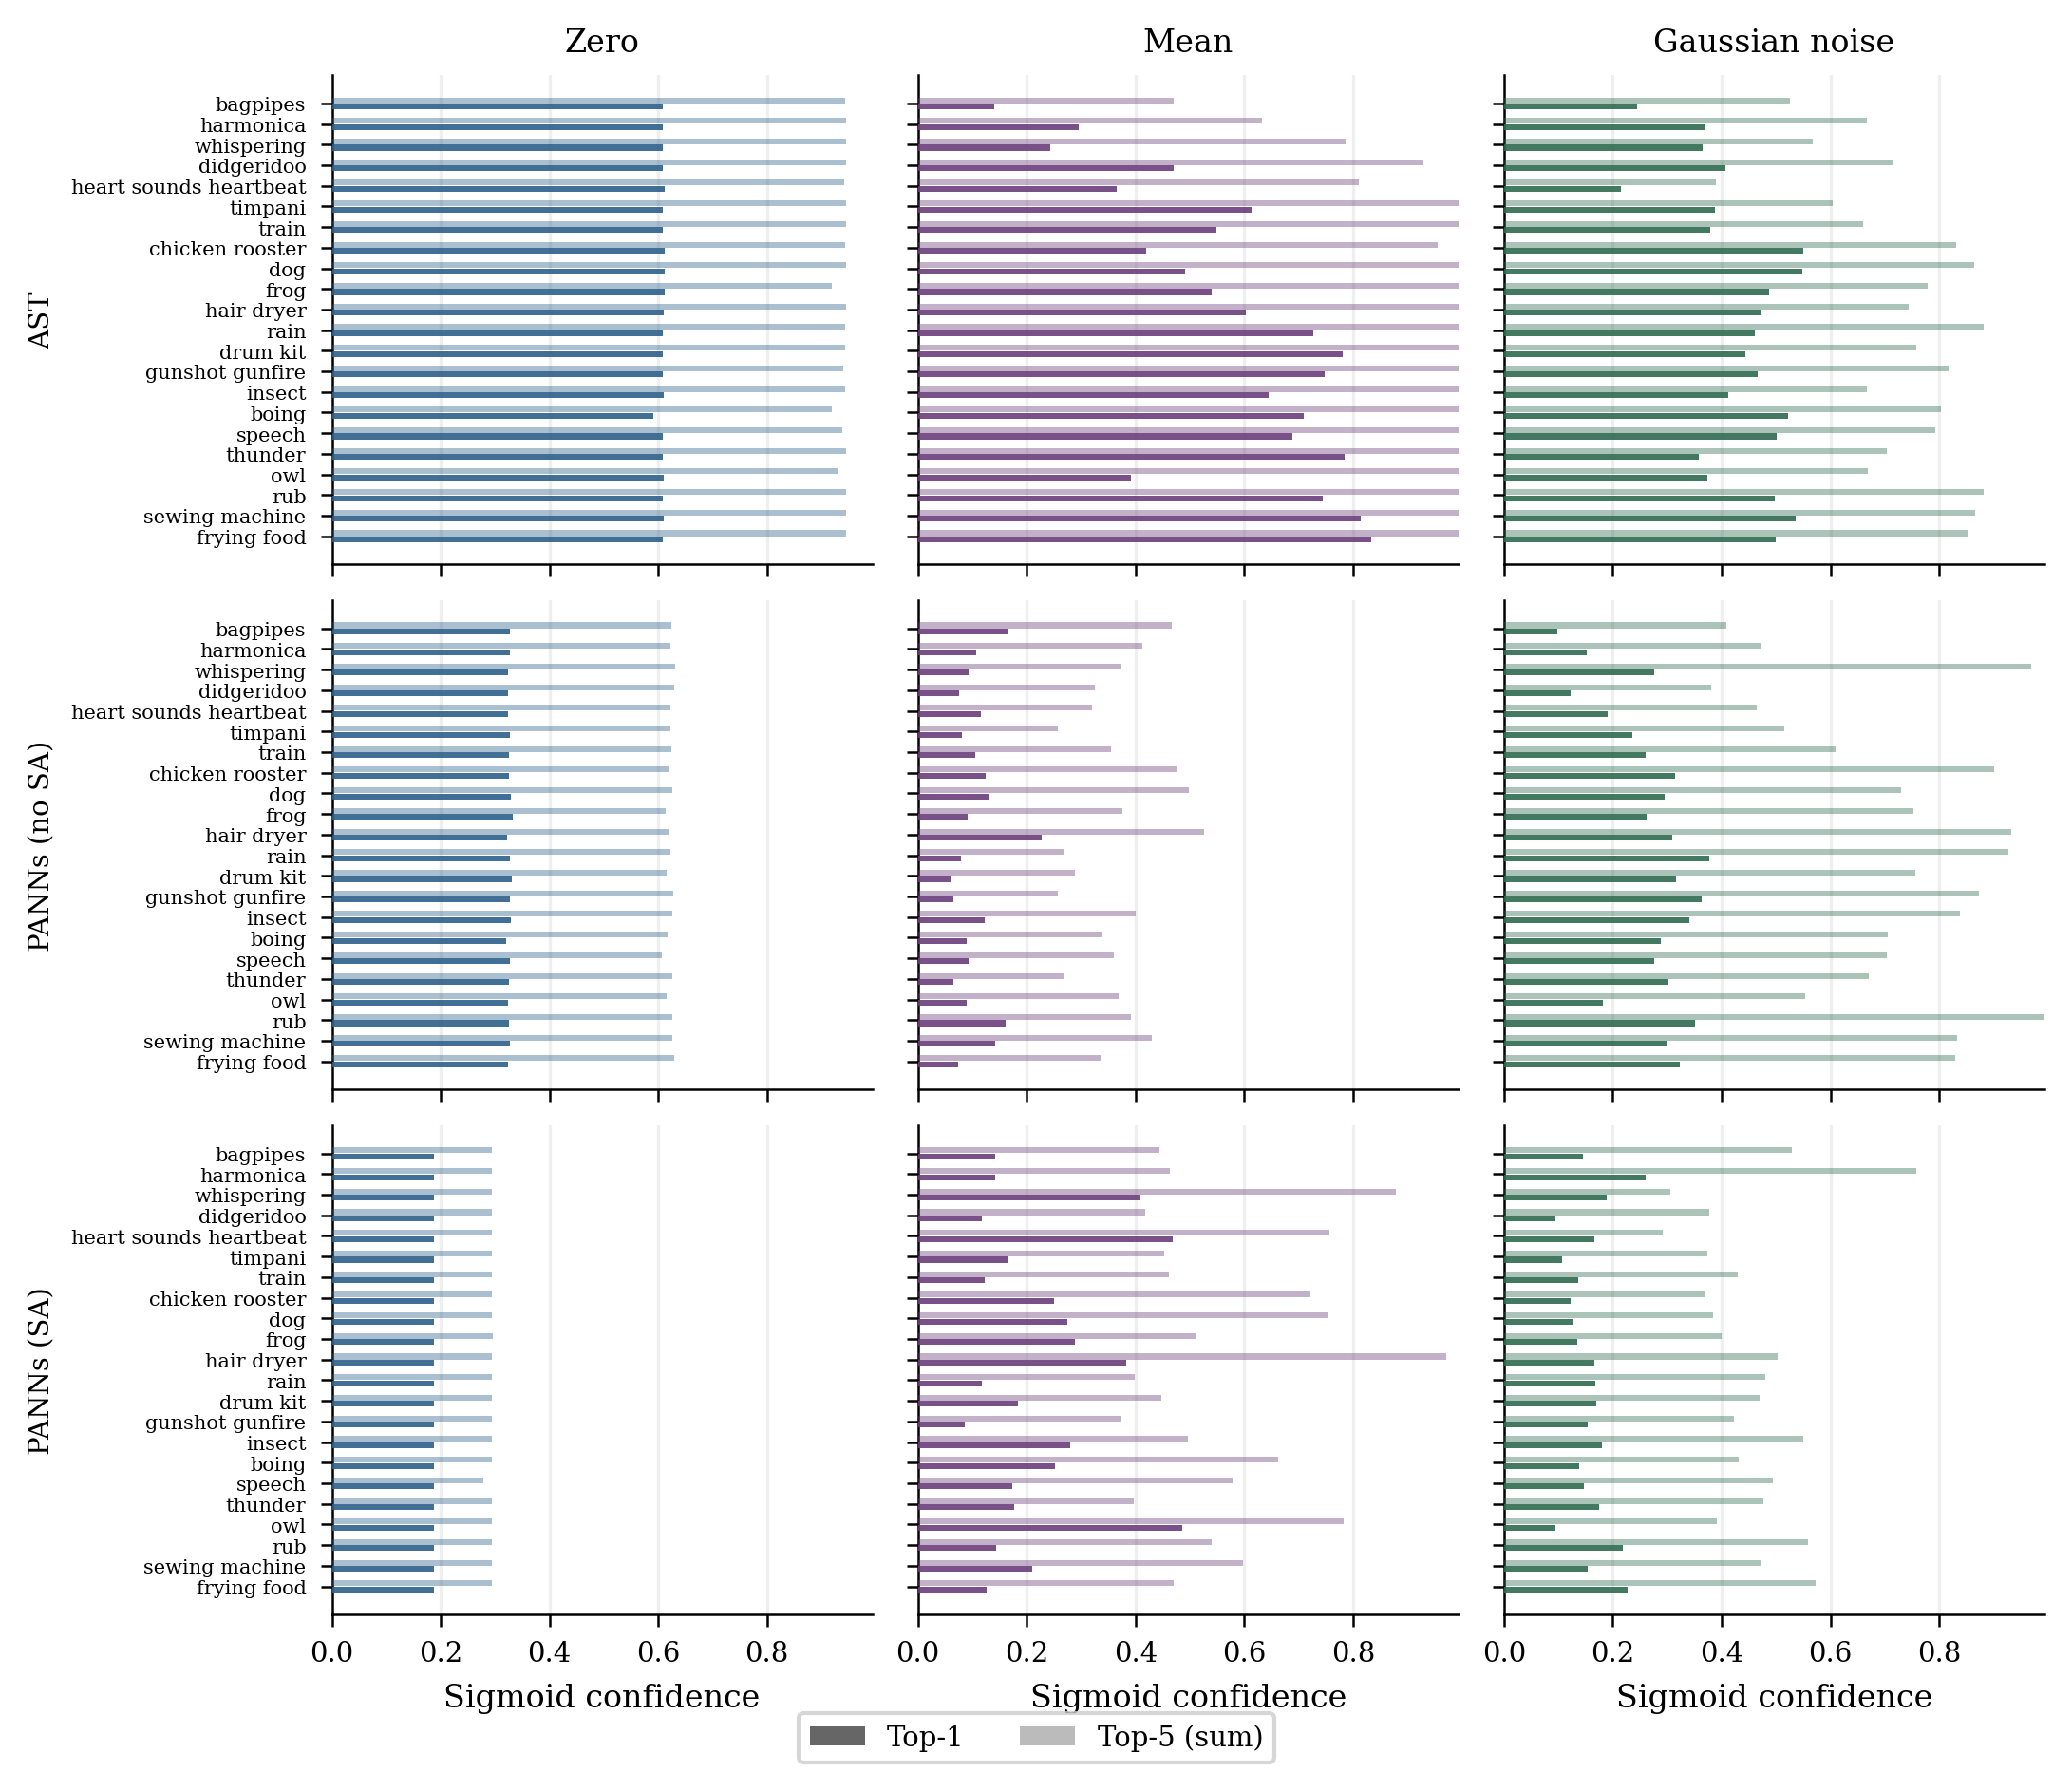

In [13]:
if "sorted_classes" not in dir():
    _zero_conf = (df_common[(df_common["model"] == "ast_wrapper") & (df_common["fill"] == "zero")]
                  .set_index("class")["top1_conf"]
                  .sort_values())
    sorted_classes = _zero_conf.index.tolist()
    y_pos = np.arange(len(sorted_classes))

fig, axes = plt.subplots(3, 3, figsize=(7.16, 6.0), sharey="row", sharex=True)

for row_i, model in enumerate(MODELS):
    for col_i, fill in enumerate(FILLS):
        ax = axes[row_i, col_i]
        subset = (
            df_common[(df_common["model"] == model) & (df_common["fill"] == fill)]
            .set_index("class")
        )
        top1 = [float(subset.loc[c, "top1_conf"]) if c in subset.index else np.nan
                for c in sorted_classes]
        top5_cumsum = [
            sum(float(subset.loc[c, f"top{k}_conf"]) for k in range(1, 6))
            if c in subset.index else np.nan
            for c in sorted_classes
        ]

        ax.barh(y_pos - 0.15, top1,        height=0.28,
                color=COLORS[fill], alpha=0.9, label="Top-1", zorder=3)
        ax.barh(y_pos + 0.15, top5_cumsum, height=0.28,
                color=COLORS[fill], alpha=0.4, label="Top-5 (sum)", zorder=3)

        if row_i == 0:
            ax.set_title(FILL_LABELS[fill])
        if col_i == 0:
            ax.set_ylabel(MODEL_LABELS[model], fontsize=7)
            ax.set_yticks(y_pos)
            ax.set_yticklabels([c.replace("_", " ") for c in sorted_classes], fontsize=5)
        if row_i == 2:
            ax.set_xlabel("Sigmoid confidence")
        ax.set_xlim(0, None)
        ax.grid(axis="x", alpha=0.2, zorder=1)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#555555", alpha=0.9, label="Top-1"),
    Patch(facecolor="#555555", alpha=0.4, label="Top-5 (sum)"),
]
fig.legend(handles=legend_handles, loc="lower center",
           bbox_to_anchor=(0.5, -0.03), ncol=2, fontsize=7, frameon=True)
plt.savefig("foc_top1_top5_confidence.pdf", format="pdf", bbox_inches="tight")
plt.show()


Row sums vs expected n=22:
  AST                  Mean             sum=22  OK
  AST                  Gaussian noise   sum=22  OK
  PANNs (no SA)        Mean             sum=22  OK
  PANNs (no SA)        Gaussian noise   sum=22  OK
  PANNs (SA)           Mean             sum=22  OK
  PANNs (SA)           Gaussian noise   sum=22  OK


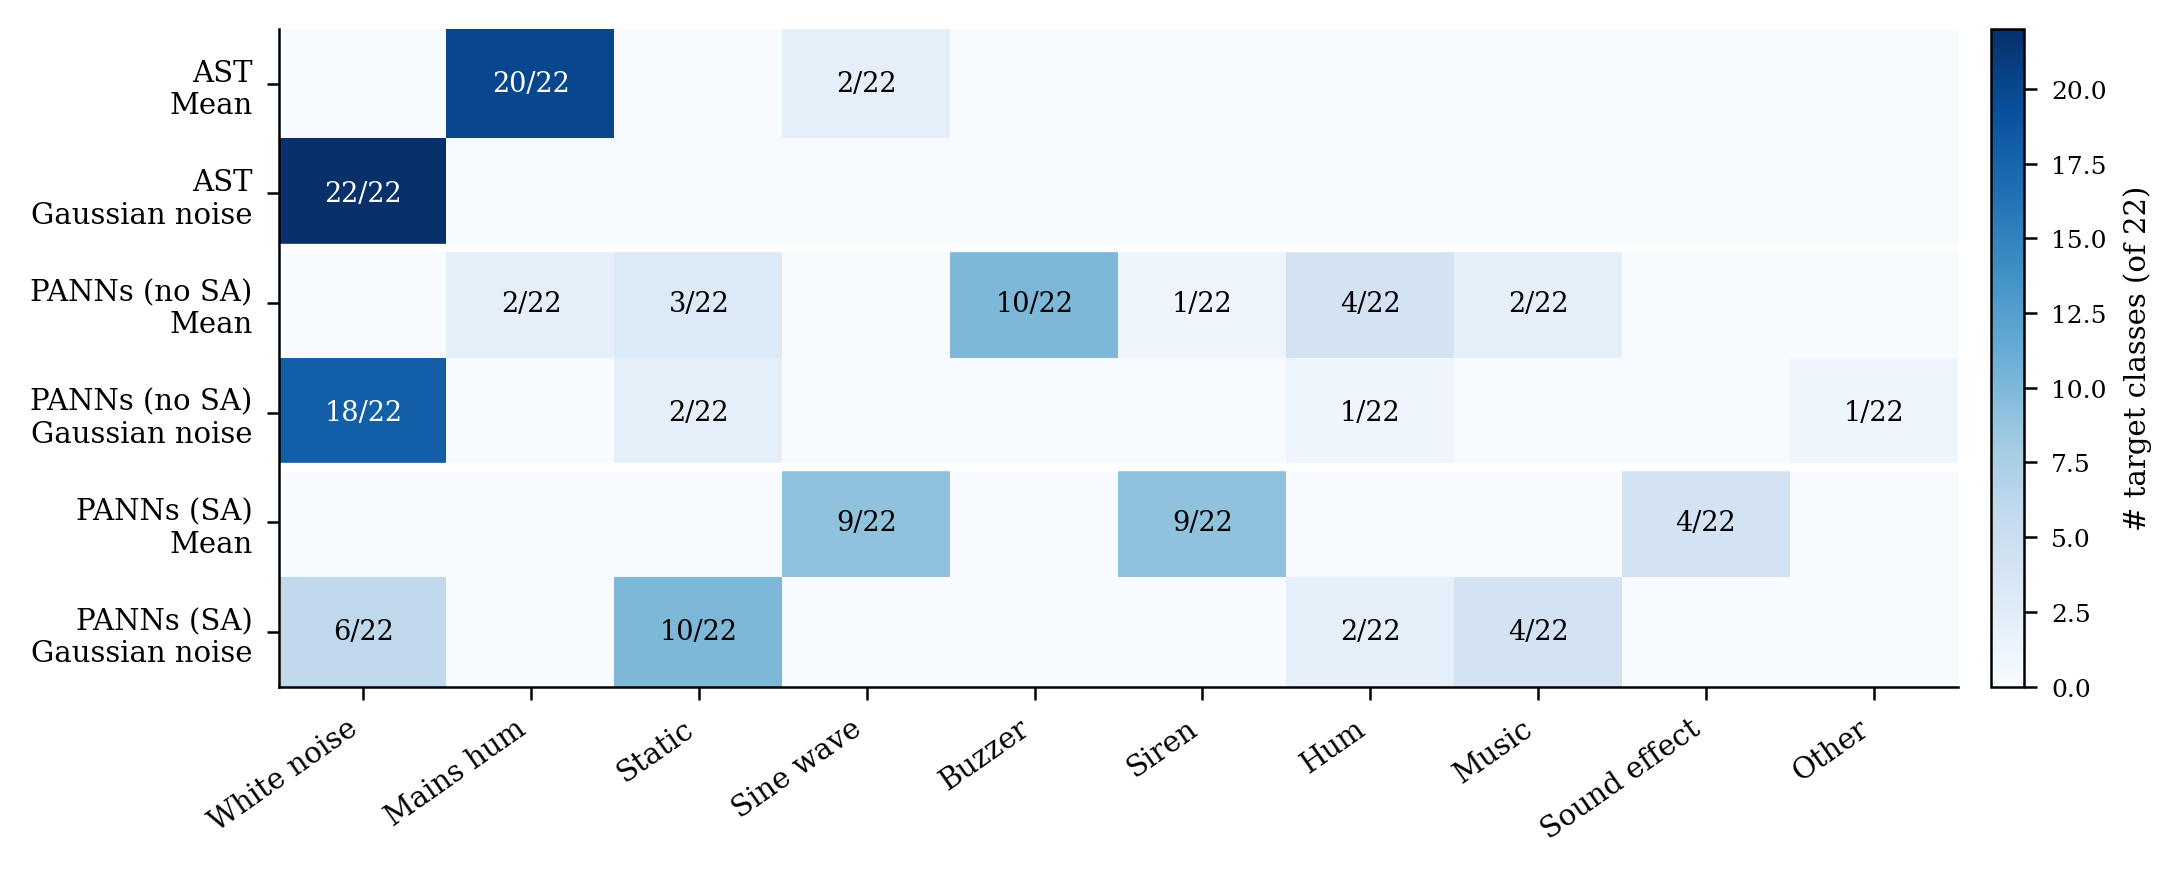

In [15]:
# ── FOC top-1 class heatmap: mean & Gaussian fills ───────────────────────────
# Uses df_common (22 classes common to all models, defined in cell 9afe44b6).

FILLS_PLOT = ["mean", "gaussian_noise"]
N          = len(common_classes)  # 22

conditions  = [(m, f) for m in MODELS for f in FILLS_PLOT]
cond_labels = [f"{MODEL_LABELS[m]}\n{FILL_LABELS[f]}" for m, f in conditions]

# Top-1 class frequency per condition
freq = {}
for model, fill in conditions:
    subset = df_common[(df_common["model"] == model) & (df_common["fill"] == fill)]
    freq[(model, fill)] = (
        subset["top1_idx"].astype(int).map(idx_to_name).value_counts()
    )

# Keep classes that are top-1 for >= 2 target classes in at least one condition
all_classes = set(c for counts in freq.values() for c in counts.index)
keep = sorted(
    [c for c in all_classes if any(freq[k].get(c, 0) >= 2 for k in freq)],
    key=lambda c: -sum(freq[k].get(c, 0) for k in freq),
)

# Build count matrix; last column = Other
matrix = np.zeros((len(conditions), len(keep) + 1))
for i, cond in enumerate(conditions):
    counts = freq[cond]
    for j, cls in enumerate(keep):
        matrix[i, j] = counts.get(cls, 0)
    matrix[i, -1] = N - matrix[i, :-1].sum()

col_labels = keep + ["Other"]
if matrix[:, -1].sum() == 0:
    matrix, col_labels = matrix[:, :-1], keep

# Sanity check
print("Row sums vs expected n=22:")
for i, cond in enumerate(conditions):
    s = int(matrix[i].sum())
    print(f"  {MODEL_LABELS[cond[0]]:20s} {FILL_LABELS[cond[1]]:15s}"
          f"  sum={s}  {'OK' if s == N else 'MISMATCH'}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.16, 2.8))

im = ax.imshow(matrix, aspect="auto", cmap="Blues", vmin=0, vmax=N)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        val = int(matrix[i, j])
        if val > 0:
            color = "white" if val > N * 0.55 else "black"
            ax.text(j, i, f"{val}/{N}", ha="center", va="center",
                    fontsize=6.5, color=color)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=35, ha="right", fontsize=7)
ax.set_yticks(range(len(cond_labels)))
ax.set_yticklabels(cond_labels, fontsize=7)

for sep in [2, 4]:
    ax.axhline(sep - 0.5, color="white", linewidth=2)

cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label("# target classes (of 22)", fontsize=7)
cb.ax.tick_params(labelsize=6)

plt.savefig("foc_top1_heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [13]:
# ── Save heatmap data to CSV ──────────────────────────────────────────────────
# Counts of target classes (of 22 common classes) producing each top-1 activation.

out = pd.DataFrame(matrix.astype(int), columns=col_labels)
out.insert(0, "n_classes", N)
out.insert(0, "fill",  [FILL_LABELS[f] for _, f in conditions])
out.insert(0, "model", [MODEL_LABELS[m] for m, _ in conditions])

out.to_csv("foc_top1_heatmap.csv", index=False)
print(out.to_string(index=False))

        model           fill  n_classes  White noise  Mains hum  Static  Sine wave  Siren  Buzzer  Hum  Music  Sound effect  Other
          AST           Mean         22            0         20       0          2      0       0    0      0             0      0
          AST Gaussian noise         22           22          0       0          0      0       0    0      0             0      0
PANNs (no SA)           Mean         22            0          2       3          0      1      10    4      2             0      0
PANNs (no SA) Gaussian noise         22           18          0       2          0      0       0    1      0             0      1
   PANNs (SA)           Mean         22            0          0       0          9      9       0    0      0             4      0
   PANNs (SA) Gaussian noise         22            6          0      10          0      0       0    2      4             0      0


In [ ]:
# ── Gaussian noise FOC summary (paper stats) ─────────────────────────────────
gn = df_common[df_common["fill"] == "gaussian_noise"].copy()
gn["top1_name"] = gn["top1_idx"].astype(int).map(idx_to_name)

hdr = "{:16s}  {:18s}  {:>12s}  {:>10s}".format(
    "Model", "Modal top-1", "Agreement", "Top-1 conf"
)
print("Gaussian Noise FOC Summary (22 common classes)")
print("=" * len(hdr))
print(hdr)
print("─" * len(hdr))
for model in MODELS:
    sub = gn[gn["model"] == model]
    modal_class = sub["top1_name"].mode()[0]
    agreement   = int((sub["top1_name"] == modal_class).sum())
    mean_conf   = float(sub[sub["top1_name"] == modal_class]["top1_conf"].mean())
    print("{:16s}  {:18s}  {:>8d}/22  {:>10.3f}".format(
        MODEL_LABELS[model], modal_class, agreement, mean_conf
    ))


In [ ]:
# ── Mean fill FOC summary (paper stats) ──────────────────────────────────────
mf = df_common[df_common["fill"] == "mean"].copy()
mf["top1_name"] = mf["top1_idx"].astype(int).map(idx_to_name)

hdr = "{:16s}  {:18s}  {:>12s}  {:>10s}".format(
    "Model", "Modal top-1", "Agreement", "Top-1 conf"
)
print("Mean Fill FOC Summary (22 common classes)")
print("=" * len(hdr))
print(hdr)
print("─" * len(hdr))
for model in MODELS:
    sub = mf[mf["model"] == model]
    modal_class = sub["top1_name"].mode()[0]
    agreement   = int((sub["top1_name"] == modal_class).sum())
    mean_conf   = float(sub[sub["top1_name"] == modal_class]["top1_conf"].mean())
    print("{:16s}  {:18s}  {:>8d}/22  {:>10.3f}".format(
        MODEL_LABELS[model], modal_class, agreement, mean_conf
    ))

print("\nTop-3 modal classes per model (mean fill):")
for model in MODELS:
    sub = mf[mf["model"] == model]
    top3 = sub["top1_name"].value_counts().head(3)
    print(f"\n  {MODEL_LABELS[model]}")
    for cls, cnt in top3.items():
        mean_conf = float(sub[sub["top1_name"] == cls]["top1_conf"].mean())
        print(f"    {cls:25s}  {cnt}/22  conf={mean_conf:.3f}")
